In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import scipy.special as sp_spec
import os
import seaborn as sns

from my_graph import build_bar_legend, set_plot, get_linear_colormap

In [2]:
def pseq_params_eglif(params):
    Qe = params['Qe']
    Te, Ee = params['Te'], params['Ee']
    Qi, Ti, Ei = params['Qi'], params['Ti'], params['Ei']
    Gl, Cm, El = params['Gl'], params['Cm'], params['El']

    Ke = params['Ke']
    Ki = params['Ki']

    return Qe, Te, Ee, Qi, Ti, Ei, Gl, Cm, El, Ke, Ki

In [3]:
## ==================================
## === Phenomenological Threshold ===
## ==================================

# EQUATION OF ERFC = vout = Fout = TF expression (Zerlaut et al. 2018)
def erfc_func(muV, sV, TvN, Vthre, Gl, Cm, alpha):
    return .5 / TvN * Gl / Cm * (sp_spec.erfc((Vthre - muV) / np.sqrt(2) / sV)) * alpha


# EQUATION OF VOUT obtained by inverting erfc_func above (Zerlaut et al. 2016)
# Used in first step of fitting procedure (fitting of V eff thre expression)
# Y = TF numerical template
def effective_Vthre(Y, muV, sV, TvN, Gl, Cm, alpha):
    Vthre_eff = muV + np.sqrt(2) * sV * sp_spec.erfcinv((1 / alpha) * (Y * 2 * TvN * Cm / Gl))  # effective threshold

    return Vthre_eff


# Polynomia expression of V eff thre - initial condition
def threshold_func(muV, sV, TvN, muGn, P0, P1, P2, P3, P4):
    """
    setting by default to True the square
    because when use by external modules, coeff[5:]=np.zeros(3)
    in the case of a linear threshold
    """

    muV0, DmuV0 = -60e-3, 10e-3
    sV0, DsV0 = 4e-3, 6e-3
    TvN0, DTvN0 = 0.5, 1.



    return P0 + P1 * (muV - muV0) / DmuV0 + \
           P2 * (sV - sV0) / DsV0 + P3 * (TvN - TvN0) / DTvN0 + P4 * np.log(muGn)
    # return P0+0*muV


In [4]:
def plot_MF_statistics(muGe, muGi, muG, muV, sV, Tv):
    media = sns.heatmap(muV)
    plt.title('Average Membrane Potential [V]')
    plt.xlabel('Fe [Hz]')
    plt.ylabel('Fi [Hz]')
    plt.show()
    var = sns.heatmap(sV)
    plt.title('Membrane Potential StDev [V]')
    plt.xlabel('Fe [Hz]')
    plt.ylabel('Fi [Hz]')
    plt.show()
    tau = sns.heatmap(Tv)
    plt.title('Autocorrelation Time [s]')
    plt.xlabel('Fe [Hz]')
    plt.ylabel('Fi [Hz]')
    plt.show()
    mug = sns.heatmap(muG)
    plt.title('Target neuron conductance [S]')
    plt.xlabel('Fe [Hz]')
    plt.ylabel('Fi [Hz]')
    plt.show()

def get_fluct_regime_varsup_eglif(Fe, Fi, XX,
                                  Qe, Te, Ee, Qi, Ti, Ei, Gl, Cm, El, Ke, Ki, P0):
    fe = Fe
    fi = Fi

    # ---------------------------- Pop cond:  mu GrC and MLI ---------------------------------------
    muGe, muGi = Qe * Ke * Te * fe, Qi * Ki * Ti * fi  # EQUAL TO EXP
    # ---------------------------- Input cond:  mu PC -----------------------------------------------
    muG = Gl + muGe + muGi  # EQUAL TO EXP
    # ---------------------------- Membrane Fluctuation Properties ----------------------------------

    """
    print('MEMBRANE FLUCT PROP')
    print('Qe: ',Qe,'\tTe: ',Te,'\tEe: ',Ee,'\tKe: ',Ke,
          '\nQi: ',Qi,'\tTi: ',Ti,'\tEi: ',Ei,'\tKi: ',Ki,
          '\nGl: ',Gl,'\t Cm: ',Cm,'\tEl: ',El)

    print('Conductances')
    print('muGe: ', muGe,'\tmuGi: ',muGi)
    """
    muV = (np.e * (muGe * Ee + muGi * Ei + Gl * El) - XX) / muG  # XX = adaptation

    """
    print('MuV without adap: ', (np.e * (muGe * Ee + muGi * Ei + Gl * El) / muG) )
    print('MuV with adap: ', muV)
    """

    muGn, Tm = muG / Gl, Cm / muG  # normalization

    Ue, Ui = Qe / muG * (Ee - muV), Qi / muG * (Ei - muV)  # EQUAL TO EXP

    # sVe= (2*Tm + Te) * (np.e * Ue *Te) ** 2 / (2* (Te + Tm)) **2 *Ke * fe
    # sVi = (2*Tm + Ti) * (np.e * Ui *Ti) ** 2 / (2* (Ti + Tm)) **2 *Ki * fi

    sVe = (2 * Tm + Te) * ((np.e * Ue * Te) / (2 * (Te + Tm))) ** 2 * Ke * fe
    sVi = (2 * Tm + Ti) * ((np.e * Ui * Ti) / (2 * (Ti + Tm))) ** 2 * Ki * fi

    sV = np.sqrt(sVe + sVi)

    fe, fi = fe + 1e-9, fi + 1e-9  # just to insure a non zero division

    Tv_num = Ke * fe * Ue ** 2 * Te ** 2 * np.e ** 2 + Ki * fi * Ui ** 2 * Ti ** 2 * np.e ** 2
    Tv = 0.5 * Tv_num / ((sV + 1e-20) ** 2)

    TvN = Tv * Gl / Cm  # normalization

    #plot_MF_statistics(muGe, muGi, muG, muV, sV, Tv)

    return muGe, muGi, muG, muV, sV + 1e-20, muGn, TvN, Tv

In [5]:
def TF_my_templateup_eglif(fe, fi, XX, alpha, Qe, Te, Ee, Qi, Ti, Ei, Gl, Cm, El, Ke, Ki,
                           P0, P1, P2, P3, P4):
    # here TOTAL (sum over synapses) excitatory and inhibitory input

    muGe, muGi, muG, muV, sV, muGn, TvN, Tv = get_fluct_regime_varsup_eglif(fe, fi, XX, Qe, Te, Ee,
                                                                            Qi, Ti, Ei, Gl, Cm, El,
                                                                            Ke, Ki,
                                                                            P0)

    Vthre = threshold_func(muV, sV, TvN, muGn, P0, P1, P2, P3, P4)

    Fout_th = erfc_func(muV, sV, TvN, Vthre, Gl, Cm, alpha)

    return Fout_th

In [6]:
def fitting_Vthre_then_Fout_eglif(Fout, Fe_eff, fiSim, w, params, alpha,
                                  maxiter=50000, xtol=1e-5):
    Gl, Cm, El = params['Gl'], params['Cm'], params['El']

    muGe, muGi, muG, muV, sV, muGn, TvN, Tv = get_fluct_regime_varsup_eglif(Fe_eff, fiSim, w,
                                                                            *pseq_params_eglif(params), -50e-3)

    #foutlim = 70.
    foutlim= Fout.max()
    Qe, Te, Ee, Qi, Ti, Ei, Gl, Cm, El, Ke, Ki = pseq_params_eglif(params)

    print('PARAMS in FITTING:')
    print('Qe=', Qe,'\nTe=', Te, '\nEe=',Ee,
          '\nQi=',Qi, '\nTi=',Ti, '\nEi=', Ei,
          '\nGl=',Gl, '\nCm=',Cm, '\nEl=',El,
          '\nKe=',Ke, '\nKi=',Ki)


    i_non_zeros = np.where((Fout > 0.) & (Fout < foutlim))  # GrC - based on trial and error
    print("Fout Limit: ", foutlim)

    Vthre_eff = effective_Vthre(Fout[i_non_zeros], muV[i_non_zeros], \
                                sV[i_non_zeros], TvN[i_non_zeros], params['Gl'], params['Cm'], alpha)

    P = [-50e-3, 0, 0, 0, 0]
    # P[:5] = Vthre_eff.mean(), 1e-3, 1e-3, 1e-3, 1e-3



    print("OPTIMIZATION STEP 1 ==========================================\nVthre Optimization")

    def Res(p):
        vthre = threshold_func(muV[i_non_zeros], sV[i_non_zeros], TvN[i_non_zeros],
                               muGn[i_non_zeros], *p)
        return np.mean((Vthre_eff - vthre) ** 2)

    # plsq = minimize(Res, P, method='SLSQP', options={'ftol': 1e-15, 'disp': True, 'maxiter': 40000})

    plsq = minimize(Res, P, options={'disp': True})
    P = plsq.x

    print('========== P output from Vthreshold opt: ', P)

    print("OPTIMIZATION STEP 2 ==========================================\nFout Optimization")

    def Res(p):
        return np.mean((Fout -
                        TF_my_templateup_eglif(Fe_eff, fiSim, w, alpha,
                                               params['Qe'], params['Te'], params['Ee'], params['Qi'], params['Ti'],
                                               params['Ei'], params['Gl'], params['Cm'], params['El'], params['Ke'],
                                               params['Ki'], *p)) ** 2)

    plsq = minimize(Res, P, method='nelder-mead',
                    options={'xtol': xtol, 'disp': True, 'maxiter': maxiter})

    # plsq = minimize(Res, P, options={'disp': True})
    P = plsq.x
    print('========== P output from Fout opt: ', P)

    print("END OF OPTIMIZATION PROCESS ==========================================")

    params['P'] = P

    return P

In [7]:
#params = np.load('/home/bcc/projects/Auto-MFM/MFM_fitting/20260109_181529_GrC_CRBL_CONFIG_AUTOMFM_AWAKE_FIT_5_tsim5_STANDARD/params.npy', allow_pickle = True).item()

In [8]:
params ={'name': 'GrC', 'N': 1, 'Gl': 2.899e-10, 'Cm': 7e-12, 'Trefrac': 0.0015, 'tm': 0.024149999999999998, 'El': -0.062, 'Vthre': -0.041, 'Vreset': -0.07, 'delta_v': 0.0003, 'kadap': 2.2e-08, 'k2': 41.0, 'k1': 311.0, 'A2': -9.399999999999998e-13, 'A1': 1e-14, 'Ie': -8.88e-13, 'Qe': 2.3000000000000003e-10, 'Te': 0.0058, 'Ee': 0.0, 'Qi': 3.6e-10, 'Ti': 0.01361, 'Ei': -0.08, 'Ke': 2.024, 'Ki': 1.77}

In [9]:
#print(params)

In [10]:
import numpy as np
z = np.load('TF_granule_cell.npz')

z.files

['tf_mean', 'tf_std', 'tags', 'freq_axis_mf', 'freq_axis_GoC']

In [11]:
MEANfreq = z['tf_mean'].T
SDfreq = z['tf_std']
Fi = z['freq_axis_GoC']
Fe = z['freq_axis_mf']

w = np.zeros((len(Fi), len(Fe)))

# frequencies saved into matrices for the broadcasting.
fiSim = np.ones((len(Fi), len(Fe)))
Fe_eff = np.ones((len(Fi), len(Fe)))

#fi (goc)
fiSim = (fiSim*Fi).T #freq changes on the row (required .T)

#Fe mossy - driving input
Fe_eff = (Fe_eff*Fe)



In [12]:
alpha = 5
P = fitting_Vthre_then_Fout_eglif(MEANfreq, Fe_eff, fiSim, w, params, alpha)

print('==================================================')
print(1e3 * np.array(P), 'Fitted P in mV')

# then we save it:
filename = 'PROVA_alpha'+str(alpha)+'_fit.npy'
print('coefficients P saved in ', filename)
np.save(filename, np.array(P))



PARAMS in FITTING:
Qe= 2.3000000000000003e-10 
Te= 0.0058 
Ee= 0.0 
Qi= 3.6e-10 
Ti= 0.01361 
Ei= -0.08 
Gl= 2.899e-10 
Cm= 7e-12 
El= -0.062 
Ke= 2.024 
Ki= 1.77
Fout Limit:  211.44444444444446
OPTIMIZATION STEP 1 ==========================================
Vthre Optimization
Optimization terminated successfully.
         Current function value: 0.000115
         Iterations: 27
         Function evaluations: 180
         Gradient evaluations: 30
========== P output from Vthreshold opt:  [-0.36319028 -0.01118275  0.01052735  0.06281765  0.09959465]
OPTIMIZATION STEP 2 ==========================================
Fout Optimization
Optimization terminated successfully.
         Current function value: 8.157685
         Iterations: 260
         Function evaluations: 423
========== P output from Fout opt:  [-0.28990751 -0.01148021  0.00534754  0.02392536  0.07372079]
END OF OPTIMIZATION PROCESS ==========================================
[-289.90751304  -11.48021015    5.34753615   23.92535548

/tmp/ipykernel_1774087/1454898044.py:53: OptimizeWarning: Unknown solver options: xtol
  plsq = minimize(Res, P, method='nelder-mead',


In [13]:
def plot_TF_numerical_vs_analytical_2D(MEANfreq, SDfreq, fiSim, Fe_eff_grc, w,
                                                     P, alpha, params, xname, barname, FOLDER, facW):

        w = w / facW
        fiSim = fiSim[:, 0]
        fiSim = np.meshgrid(np.zeros(Fe_eff_grc.shape[1]), fiSim)[1]
        levels = np.unique(fiSim)  # to store for colors

        if P is not None:
            params['P'] = P

        # # #### FIGURE AND COLOR GRADIENT STUFF

        fig1 = plt.figure(figsize=(6, 4))
        plt.subplots_adjust(bottom=.2, left=.15, right=.85, wspace=.2)
        ax = plt.subplot2grid((1, 8), (0, 0), colspan=7)
        ax_cb = plt.subplot2grid((1, 8), (0, 7))

        # -- Setting up a colormap that's a simple transtion
        mymap = plt.cm.viridis
        #mymap = get_linear_colormap()
        build_bar_legend(np.round(levels, 1), levels.size, ax_cb, mymap,
                         label=barname + ' ($\\nu_i$)' + ' [Hz]')  # BUILD THE COLOR SCALE BAR

        for i in range(levels.size):
            SIMvector = MEANfreq[i][:]
            SDvector = SDfreq[i][:]
            feSim = Fe_eff_grc[i][:]
            feth = np.linspace(feSim.min(), feSim.max(), int(1e2))
            fi = fiSim[i][0]
            wee = w[i][0]

            #print("Adap:", wee)

            _, _, _, muV, sV, muGn, TvN, Tv = get_fluct_regime_varsup_eglif(feSim, fi, wee,
                                                                                   *pseq_params_eglif(params),
                                                                                   P[0])

            # Fout_th = erfc_func(muV, sV, TvN, -56e-3, params['Gl'], params['Cm']) # JUST FIXING THE THRESHOLD FOR NOW

            Fout_th = erfc_func(muV, sV, TvN, threshold_func(muV, sV, TvN, muGn, *P), params['Gl'], params['Cm'], alpha)

            # cond = Fout_th < 40.
            cond = Fout_th <= Fout_th.max()

            r = (float(levels[i]) - levels.min()) / (levels.max() - levels.min())
            #### plot dei pallini - template numerico
            ax.errorbar(feSim[cond], SIMvector[cond], yerr=SDvector[cond], \
                        color=mymap(r, 1), marker='D', ms=5, capsize=3, elinewidth=1, lw=0)

            #### plot delle linee - espressione con error function di TF
            ax.plot(feSim[cond], Fout_th[cond], color=mymap(r, 1))


        set_plot(ax, ['bottom', 'left'], xlabel=xname+' ($\\nu_{e}$)'+ ' [Hz]', \
                 ylabel='$\\nu_{out}$'+ ' [Hz]')

        #### SOLO PER PLOT ZEBRINE POS NEG
        #ax.set_ylim(0, 125)
        #ax.set_yticks(np.linspace(0, 125, 5, dtype =int))


        ## quantitative analysis
        diff = np.absolute(np.array([SIMvector - Fout_th]))
        print('QUANTUTATIVE SCORE!!!!!\n diff (numTF-SemiAnalyticTF)', diff)


        print('----------------------------------------')
        diff_mean = diff.mean()
        diff_sd = diff.std()
        diff_max = diff.max()
        diff_min = diff.min()
        print('Mean diff +- stdev (numTF-SemiAnalyticTF)', diff_mean, '+-', diff_sd)
        print('Min diff', diff_min)

        plt.savefig(FOLDER+'_alfa'+str(alpha)+'.pdf',dpi=300)

        plt.show()


def call_plot_fitting(FOLDER, alpha, MEANfreq, sd_freq, w, fiSim, Fe_m_eff, params, xname, barname):
    max_index_fi = len(fiSim)
    max_ind_fe = len(Fe_m_eff)

    MEANfreq = MEANfreq[:max_index_fi, :max_ind_fe]
    SDfreq = sd_freq[:max_index_fi, :max_ind_fe]
    fiSim = fiSim[:max_index_fi, :max_ind_fe]
    Fe_eff_m = Fe_m_eff[:max_index_fi, :max_ind_fe]
    w = w[:max_index_fi, :max_ind_fe]
    P = np.load(FOLDER + '_alpha' + str(alpha) + '_fit.npy', allow_pickle=True)

    plot_TF_numerical_vs_analytical_2D(MEANfreq, SDfreq, fiSim, Fe_eff_m, w,
                                                 P, alpha, params, xname, barname, FOLDER, facW=1)

QUANTUTATIVE SCORE!!!!!
 diff (numTF-SemiAnalyticTF) [[0.2740736  0.3024512  0.33449139 0.37065068 0.41143936 0.45742664
  0.50924611 0.56760147 0.63327251 0.70712133 0.79009872 0.7721396
  0.98772513 0.99366717 1.23578142 1.27111612 1.32351372 1.28361669
  1.26442848 1.71242944]]
----------------------------------------
Mean diff +- stdev (numTF-SemiAnalyticTF) 0.8101145395230824 +- 0.4128016768073988
Min diff 0.27407360077670256


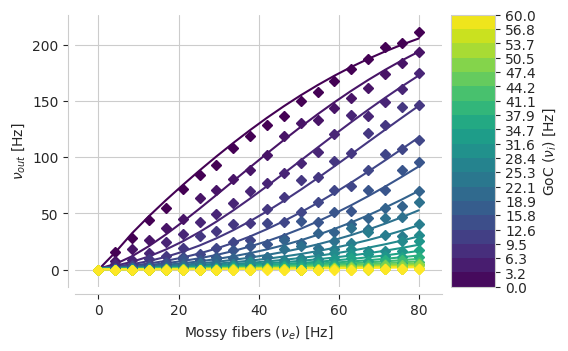

In [14]:
xname = 'Mossy fibers'
barname = 'GoC'
FOLDER = 'PROVA'
call_plot_fitting(FOLDER, alpha, MEANfreq, SDfreq, w, fiSim, Fe_eff, params, xname, barname)